### Linear Regression Tutorial using Workflow API

This notebook demonstrates a linear regression tutorial using the Workflow Interface. The key steps include:

1. **Model Definition**:
    - Define a linear regression model with Mean Squared Error (MSE) as the loss function.

2. **Synthetic Data Generation**:
    - Generate synthetic datasets for training and validation.
    - Shard the dataset among multiple collaborators for federated learning.

3. **Federated Learning Workflow**:
    - Define a federated learning workflow using the `FederatedFlow` class.
    - Implement tasks for the aggregator and collaborators, including model validation, training, and aggregation.

4. **Training and Evaluation**:
    - Train the model locally to establish a baseline.
    - Execute the federated learning workflow to train the model across multiple collaborators.
    - Plot and analyze the aggregated model's performance over multiple rounds.

By the end of this tutorial, you will understand how to set up and execute a federated learning using workflow interface for a linear regression model.

### Getting Started

First we start by installing the necessary dependencies for the workflow interface and importing the relevant libraries

In [1]:
!pip install git+https://github.com/securefederatedai/openfl.git
!pip install -r workflow_interface_requirements.txt
!pip install matplotlib

# Uncomment this if running in Google Colab and set USERNAME if running in docker container.
#!pip install -r https://raw.githubusercontent.com/intel/openfl/develop/openfl-tutorials/experimental/workflow/workflow_interface_requirements.txt
#import os
#os.environ["USERNAME"] = "colab"

  Cloning https://github.com/securefederatedai/openfl.git to /tmp/pip-req-build-2qk1gq4s
  Running command git clone --filter=blob:none --quiet https://github.com/securefederatedai/openfl.git /tmp/pip-req-build-2qk1gq4s


  Resolved https://github.com/securefederatedai/openfl.git to commit cd71616c3c09592e0e7193ad0fa60ea8f4cf54a4


  Installing build dependencies ... -

 \

 |

...

  Preparing metadata (pyproject.toml) ... -

 done



[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import torch as pt
import torch.utils.data as data
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from typing import List, Union
import random
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.pylab import rcParams

import warnings
warnings.filterwarnings("ignore")

Next, define a linear regression model with Mean Squared Error (MSE) as the loss function. Train this linear model locally on a synthetic dataset to establish a baseline solution.

In [3]:
class LinRegLasso:
    def __init__(self, n_feat: int) -> None:
        self.weights = np.ones((n_feat + 1)) # (n_feat + 1,) weights + bias

    def predict(self, feature_vector: Union[np.ndarray, List[int]]) -> float:
        '''
        feature_vector may be a list or have shape (n_feat,)
        or it may be a bunch of vectors (n_vec, nfeat)
        '''
        feature_vector = np.array(feature_vector)
        if len(feature_vector.shape) == 1:
            feature_vector = feature_vector[:,np.newaxis]
        assert feature_vector.shape[-1] == self.weights.shape[0] - 1, \
            f"sample shape is {feature_vector.shape} and weights shape is f{self.weights}"

        return self.weights @ np.concatenate((feature_vector.T, [[1]*feature_vector.shape[0]]))

    def mse(self, X: np.ndarray, Y: np.ndarray) -> float:
        Y_hat = self.predict(X)
        return np.sum((Y - Y_hat)**2) / Y.shape[0]

    def _update_weights(self, X: np.ndarray, Y: np.ndarray, lr: float, wd: float) -> None:
        '''
        X: (n_samples, n_features)
        Y: (n_samples,)
        self.weights: (n_features + 1)
        
        Cost function is MSE: (y - W*X - b)**2;
        its derivative with resp to any x is -2*X*(y - W*X - b),
        and with resp to b is -2*(y - W*X - b).
        
        Regularisation function is L1 |W|;
        its derivative is SIGN(w)
        '''
        predictions = self.predict(X)
        error = Y - predictions # (n_samples,)
        X_with_bias = np.concatenate((X.T, [[1]*X.shape[0]])).T
        updates = -2 * X_with_bias.T @ error / Y.shape[0]
        regression_term = np.sign(self.weights)

        self.weights = self.weights - lr * updates + wd * regression_term

    def fit(self, X: np.ndarray, Y: np.ndarray,
            n_epochs: int, lr: float, wd: float,
            silent: bool=False) -> None:
        for i in range(n_epochs):
            self._update_weights(X, Y, lr, wd)
            mse = self.mse(X, Y)
            if not silent:
                print(f'epoch: {i}, \t MSE: {mse}')

    def train(self, train_data, lr, wd, epochs):
        # Initialize lists to store all data
        all_X = []
        all_Y = []

        # Iterate through the DataLoader to get all data
        for batch_idx, (X_batch, Y_batch) in enumerate(train_data):
            all_X.append(X_batch.numpy())  # Convert to NumPy and append
            all_Y.append(Y_batch.numpy())  # Convert to NumPy and append

        # Concatenate all batches into NumPy arrays
        X = np.concatenate(all_X, axis=0)
        Y = np.concatenate(all_Y, axis=0)
        self.fit(X, Y, epochs, lr, wd, silent=True)
        train_mse = self.mse(X, Y)
        return train_mse

def validate(my_model, val_loader):
    total_mse = 0.0
    num_samples = 0

    for batch_idx, (X, Y) in enumerate(val_loader):
        X = X.numpy()
        Y = Y.numpy()

        total_mse += my_model.mse(X, Y) * len(X)  # Multiply MSE by batch size
        num_samples += len(X)  # Count total number of samples

    validation_mse = total_mse / num_samples  # Average MSE across all samples
    return validation_mse

In [4]:
# Define input array with angles from 60deg to 300deg converted to radians
x = np.array([i*np.pi/180 for i in range(60,300,4)])
np.random.seed(10)  # Setting seed for reproducibility
y = np.sin(x) + np.random.normal(0,0.15,len(x))
#plt.plot(x,y,'.')

In [5]:
lr_model = LinRegLasso(1)
wd = 0.0001
lr = 0.08
epochs = 100

print(f"Initial MSE: {lr_model.mse(x,y)}")
lr_model.fit(x[:,np.newaxis],y, epochs, lr, wd, silent=True)
print(f"Final MSE: {lr_model.mse(x,y)}")
print(f"Final parameters: {lr_model.weights}")

Initial MSE: 20.442839563960476
Final MSE: 0.05885962951284361
Final parameters: [-0.56894409  1.784573  ]


Federated Averaging Function

The following cell defines the `FedAvg` function, which simulates federated averaging for `LinRegLasso` models. This function takes a list of model instances from collaborators and optionally a list of weights for weighted averaging. It returns an updated global model with averaged weights.

In [6]:
def FedAvg(models, weights=None):
    """
    Simulates federated averaging for LinRegLasso models.

    Args:
        models (list): List of LinRegLasso model instances from collaborators.
        weights (list, optional): List of weights for each model, used for weighted averaging. Defaults to None, indicating equal weights.

    Returns:
        LinRegLasso: Updated global model with averaged weights.
    """
    new_model = models[0]  # Use the first model as a base
    all_weights = [model.weights for model in models]  # Get weights from all models
    new_model.weights = np.average(all_weights, axis=0, weights=weights)   # Average the weights
    return new_model

We define a federated learning workflow using the `FederatedFlow` class, which extends `FLSpec`. The workflow includes defining the tasks which will be executed by aggregator and collabarators.

In [7]:
from openfl.experimental.workflow.interface import FLSpec, Aggregator, Collaborator
from openfl.experimental.workflow.runtime import LocalRuntime
from openfl.experimental.workflow.placement import aggregator, collaborator

class FederatedFlow(FLSpec):

    def __init__(self, model=None, optimizer=None, rounds=3, **kwargs):
        super().__init__(**kwargs)
        self.model = model
        self.rounds = rounds
        self.aggregated_mse_history = []
        self.train_loss_history = []

    @aggregator
    def start(self):
        print(f'Performing initialization for model')
        self.collaborators = self.runtime.collaborators
        self.current_round = 0
        self.next(self.aggregated_model_validation, foreach='collaborators')

    @collaborator
    def aggregated_model_validation(self):
        print(f'Performing aggregated model validation for collaborator {self.input}')
        self.agg_validation_score = validate(self.model, self.test_loader)
        print(f'{self.input} value of {self.agg_validation_score}')
        self.next(self.train)

    @collaborator
    def train(self):
        self.wd = 0.0001
        self.lr = 0.08
        self.epochs = 100
        self.loss = self.model.train(self.train_loader, self.lr, self.wd, self.epochs)
        self.next(self.local_model_validation)

    @collaborator
    def local_model_validation(self):
        self.local_validation_score = validate(self.model, self.test_loader)
        print(
            f'Doing local model validation for collaborator {self.input}: {self.local_validation_score}')
        self.next(self.join)

    @aggregator
    def join(self, inputs):
        self.average_train_loss = sum(input.loss for input in inputs) / len(inputs)
        self.aggregated_model_mse = sum(
            input.agg_validation_score for input in inputs) / len(inputs)
        self.local_model_mse = sum(
            input.local_validation_score for input in inputs) / len(inputs)
        self.train_loss_history.append(self.average_train_loss)
        self.aggregated_mse_history.append(self.aggregated_model_mse)
        print(f'Average aggregated model validation values = {self.aggregated_model_mse}')
        print(f'Average training loss = {self.average_train_loss}')
        print(f'Average local model validation values = {self.local_model_mse}')
        self.model = FedAvg([input.model for input in inputs])
  
        self.current_round += 1
        if self.current_round < self.rounds:
            self.next(self.aggregated_model_validation,
                      foreach='collaborators')
        else:
            self.next(self.end)

    @aggregator
    def end(self):
        print(f'This is the end of the flow')

Aggregator step "start" registered
Collaborator step "aggregated_model_validation" registered
Collaborator step "train" registered
Collaborator step "local_model_validation" registered
Aggregator step "join" registered
Aggregator step "end" registered


Now we can generate the training and validation datasets and shard the dataset among the collaborators. This allows each collaborator to have their own subset of the data for federated learning. The `split` method provides data loaders for training and testing for each collaborator.

In [8]:
def generate_synthetic(rank: int, n_samples: int, noise: float):
    """
    Generate synthetic data for linear regression.

    Args:
        rank (int): Seed for random number generation.
        n_samples (int): Number of samples to generate.
        noise (float): Standard deviation of the Gaussian noise added to the y values.

    Returns:
        np.ndarray: Generated x values.
        np.ndarray: Generated y values.
    """
    np.random.seed(rank)
    n_samples = max(n_samples, 10)
    interval = 240
    x_start = 60

    x = np.random.rand(n_samples, 1) * interval + x_start
    x *= np.pi / 180

    y = np.sin(x) + np.random.normal(0, noise, size=(n_samples,1))
    y = y.reshape(-1)

    return x, y

class SyntheticFederatedDataset:
    def __init__(self, num_collaborators=2, batch_size=1, num_samples=10, **kwargs):
        self.batch_size = batch_size
        X, y = generate_synthetic(rank=42, n_samples=num_samples, noise=0.1)
        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.float32)

        self.X_train_all = X[:int(0.8 * len(X))]
        self.y_train_all = y[:int(0.8 * len(y))]
        
        self.X_test_all = X[int(0.8 * len(X)):]
        self.y_test_all = y[int(0.8 * len(y)):]

        min_samples = max(len(self.X_train_all) // num_collaborators, 1)

        while len(self.X_test_all) < num_collaborators or any(len(chunk) < 1 for chunk in self.X_train_all):
            X, y = generate_synthetic(rank=42, n_samples=len(self.X_train_all) + len(self.X_valid_all) + 1, noise=0.1)
            X = np.array(X, dtype=np.float32)
            y = np.array(y, dtype=np.float32)
            self.X_train_all = X[:int(0.9 * len(X))]
            self.X_test_all = X[int(0.9 * len(X)):]
            self.y_train_all = y[:int(0.9 * len(y))]
            self.y_test_all = y[int(0.9 * len(y)):]

        self.X_train_all = np.array_split(self.X_train_all, num_collaborators)
        self.X_test_all = np.array_split(self.X_test_all, num_collaborators)
        self.y_train_all = np.array_split(self.y_train_all, num_collaborators)
        self.y_test_all = np.array_split(self.y_test_all, num_collaborators)

    def split(self, index):
        return {
            "train_loader":
                data.DataLoader(
                    data.TensorDataset(
                        pt.from_numpy(self.X_train_all[index]),
                        pt.from_numpy(self.y_train_all[index])
                    ),
                    batch_size=self.batch_size, shuffle=True
                ),
            "test_loader":
                data.DataLoader(
                    data.TensorDataset(
                        pt.from_numpy(self.X_test_all[index]),
                        pt.from_numpy(self.y_test_all[index])
                    ),
                    batch_size=self.batch_size, shuffle=True
                )
        }

We will set up the aggregator and collaborators for the federated learning and initialize the local runtime environment. 

In [9]:
aggregator = Aggregator()
aggregator.private_attributes = {}

collaborator_names = ['Bangalore', 'Paris', 'Texas', 'Seoul']
collaborators = [Collaborator(name=name) for name in collaborator_names]
synthetic_federated_dataset = SyntheticFederatedDataset(num_collaborators=len(collaborator_names), num_samples=2000, batch_size=20)

def callable_to_initialize_collaborator_private_attributes(index):
    private_attributes = synthetic_federated_dataset.split(index)
    return private_attributes

collaborators = []
for idx, collaborator_name in enumerate(collaborator_names):
    collaborators.append(
        Collaborator(
            name=collaborator_name, num_cpus=1.0, num_gpus=0.0,
            private_attributes_callable=callable_to_initialize_collaborator_private_attributes,
            index=idx
        )
    )

local_runtime = LocalRuntime(aggregator=aggregator, collaborators=collaborators, backend='single_process')
print(f'Local runtime collaborators = {local_runtime.collaborators}')

Local runtime collaborators = ['Bangalore', 'Paris', 'Texas', 'Seoul']


Now that we have our flow and runtime defined, let's run the experiment!

In [10]:
model = lr_model
optimizer = None
flflow = FederatedFlow(model, optimizer, rounds=10, checkpoint=True)
flflow.runtime = local_runtime
flflow.run()

Created flow FederatedFlow

Calling start
Performing initialization for model
Saving data artifacts for start
Saved data artifacts for start



Calling aggregated_model_validation
Performing aggregated model validation for collaborator Bangalore
Bangalore value of 0.044746321200235036


Saving data artifacts for aggregated_model_validation
Saved data artifacts for aggregated_model_validation

Calling train
Saving data artifacts for train
Saved data artifacts for train

Calling local_model_validation
Doing local model validation for collaborator Bangalore: 0.040847566728546204
Saving data artifacts for local_model_validation
Saved data artifacts for local_model_validation
Should transfer from local_model_validation to join

Calling aggregated_model_validation
Performing aggregated model validation for collaborator Paris
Paris value of 0.043642962162457256
Saving data artifacts for aggregated_model_validation
Saved data artifacts for aggregated_model_validation

Calling train


Saving data artifacts for train


Saved data artifacts for train

Calling local_model_validation
Doing local model validation for collaborator Paris: 0.04354140642954988
Saving data artifacts for local_model_validation
Saved data artifacts for local_model_validation
Should transfer from local_model_validation to join

Calling aggregated_model_validation
Performing aggregated model validation for collaborator Texas
Texas value of 0.05598547352161079
Saving data artifacts for aggregated_model_validation
Saved data artifacts for aggregated_model_validation

Calling train
Saving data artifacts for train
Saved data artifacts for train

Calling local_model_validation
Doing local model validation for collaborator Texas: 0.04819927605653108
Saving data artifacts for local_model_validation
Saved data artifacts for local_model_validation
Should transfer from local_model_validation to join

Calling aggregated_model_validation
Performing aggregated model validation for collaborator Seoul
Seoul value of 0.04510363863879993


...


Calling join
Average aggregated model validation values = 0.04408565920663684
Average training loss = 0.04147929374690434
Average local model validation values = 0.04401384912449341
Saving data artifacts for join
Saved data artifacts for join

Calling aggregated_model_validation
Performing aggregated model validation for collaborator Bangalore
Bangalore value of 0.040592807415752954
Saving data artifacts for aggregated_model_validation
Saved data artifacts for aggregated_model_validation

Calling train


Saving data artifacts for train
Saved data artifacts for train

Calling local_model_validation
Doing local model validation for collaborator Bangalore: 0.040770280108462335
Saving data artifacts for local_model_validation
Saved data artifacts for local_model_validation
Should transfer from local_model_validation to join

Calling aggregated_model_validation
Performing aggregated model validation for collaborator Paris
Paris value of 0.04408015937050435
Saving data artifacts for aggregated_model_validation
Saved data artifacts for aggregated_model_validation

Calling train
Saving data artifacts for train
Saved data artifacts for train

Calling local_model_validation
Doing local model validation for collaborator Paris: 0.04411955076014453
Saving data artifacts for local_model_validation
Saved data artifacts for local_model_validation
Should transfer from local_model_validation to join

Calling aggregated_model_validation
Performing aggregated model validation for collaborator Texas
Texas 

Saving data artifacts for aggregated_model_validation
Saved data artifacts for aggregated_model_validation

Calling train
Saving data artifacts for train
Saved data artifacts for train

Calling local_model_validation
Doing local model validation for collaborator Texas: 0.04754964352557856
Saving data artifacts for local_model_validation
Saved data artifacts for local_model_validation
Should transfer from local_model_validation to join

Calling aggregated_model_validation
Performing aggregated model validation for collaborator Seoul
Seoul value of 0.044107702780371565
Saving data artifacts for aggregated_model_validation
Saved data artifacts for aggregated_model_validation

Calling train
Saving data artifacts for train


Saved data artifacts for train

Calling local_model_validation
Doing local model validation for collaborator Seoul: 0.04361592216110197
Saving data artifacts for local_model_validation
Saved data artifacts for local_model_validation
Should transfer from local_model_validation to join

Calling join
Average aggregated model validation values = 0.04408565930576259
Average training loss = 0.04147929375076419
Average local model validation values = 0.04401384913882185
Saving data artifacts for join
Saved data artifacts for join



Calling end
This is the end of the flow
Saving data artifacts for end
Saved data artifacts for end


In [11]:
print(f'\nFinal aggregated MSE for {flflow.rounds} rounds of training: {flflow.aggregated_model_mse}')
print(f'\nFinal loss model for {flflow.rounds} rounds of training: {flflow.train_loss_history}')
print(f'\nFinal parameters: {flflow.model.weights}')
print(f'\n Aggregated model MSE History : {flflow.aggregated_mse_history}')


Final aggregated MSE for 10 rounds of training: 0.04408565930576259

Final loss model for 10 rounds of training: [np.float64(0.04151453252855894), np.float64(0.04147544411684677), np.float64(0.04147861773070708), np.float64(0.04147919896562365), np.float64(0.04147928079174016), np.float64(0.04147929198491555), np.float64(0.04147929351067698), np.float64(0.04147929371857666), np.float64(0.04147929374690434), np.float64(0.04147929375076419)]

Final parameters: [-0.62239278  1.95299309]

 Aggregated model MSE History : [np.float64(0.04736959888077575), np.float64(0.04402754362476864), np.float64(0.04406915775945911), np.float64(0.04408324573417868), np.float64(0.04408532707783288), np.float64(0.04408561397502496), np.float64(0.04408565314065349), np.float64(0.0440856584791654), np.float64(0.04408565920663684), np.float64(0.04408565930576259)]


Plot the training Mean Squared Error (MSE) over the training rounds.

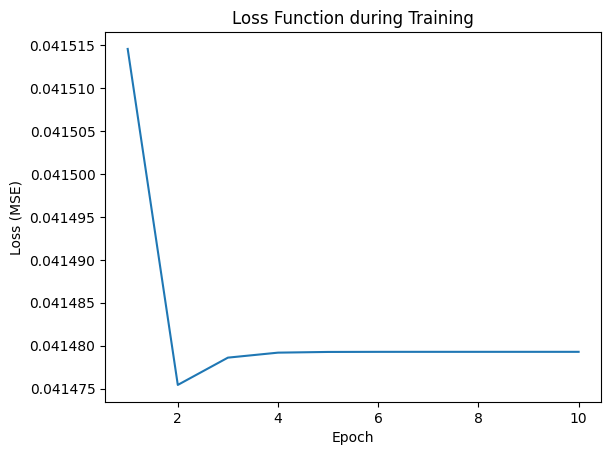

In [12]:
plt.plot(range(1, flflow.rounds + 1), flflow.train_loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss Function during Training')
plt.show()

Plot the aggregated model Mean Squared Error (MSE) over the training rounds.

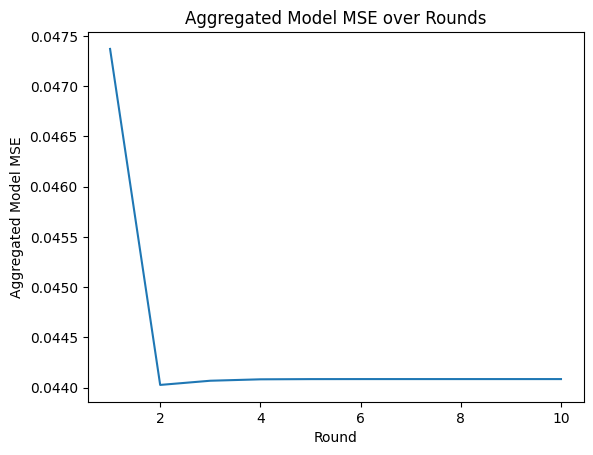

In [13]:
plt.plot(range(1, flflow.rounds + 1), flflow.aggregated_mse_history)
plt.xlabel('Round')
plt.ylabel('Aggregated Model MSE')
plt.title('Aggregated Model MSE over Rounds')
plt.show()

Now we can validate how our final trained model performs on any random dataset.

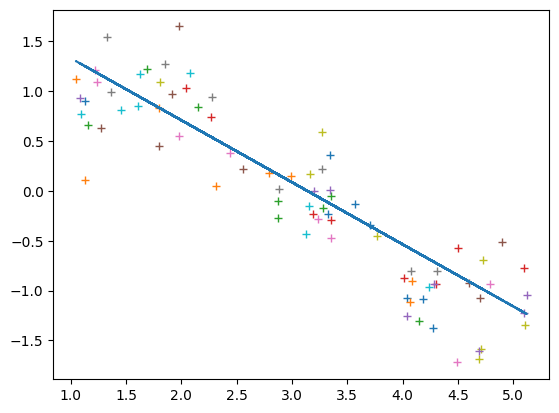

In [14]:
n_cols = 20
n_samples = 4
interval = 240
x_start = 60
noise = 0.3

X = None
final_model = flflow.model # Get the final model after training
for rank in range(n_cols):
    np.random.seed(rank)  # Setting seed for reproducibility
    x = np.random.rand(n_samples, 1) * interval + x_start
    x *= np.pi / 180
    X = x if X is None else np.vstack((X,x))
    y = np.sin(x) + np.random.normal(0, noise, size=(n_samples, 1))
    plt.plot(x,y,'+')
    
X.sort()    
Y_hat = final_model.predict(X)
plt.plot(X,Y_hat,'--')